In [29]:
import scipy
import numpy as np
import matplotlib.pyplot as plt

# Discrete

## Bernoulli

In [30]:
dist = scipy.stats.bernoulli(p=0.3)
dist.support()

(np.int64(0), np.int64(1))

In [31]:
dist.rvs()

1

## Categocial

In [32]:
categories = [0, 1, 2]
probabilities = [0.1, 0.3, 0.6]
cat_dist = scipy.stats.rv_discrete(values=(categories, probabilities))
cat_dist.rvs()

np.int64(2)

## Binomial

In [33]:
dist = scipy.stats.binom(1000, 0.6)
dist.rvs()

603

## Multinomial

In [34]:
# usual use of of multinomial
dist = scipy.stats.multinomial(1000, p=(0.1, 0.3, 0.6))
dist.rvs()

array([[112, 322, 566]])

In [35]:
# use of OHE variant of multinomial
dist = scipy.stats.multinomial(1, p=(0.1, 0.3, 0.6))
dist.rvs()

array([[0, 0, 1]])

# Continuous

## Beta

In [36]:
dist = scipy.stats.beta(2, 4)
dist.rvs()

np.float64(0.12579007296875522)

In [37]:
distr = scipy.stats.beta(2, 4)
rvs = distr.rvs(10000)
rvs.min(), rvs.max()
assert np.all(rvs >= 0)
assert np.all(rvs <= 1)

In [38]:
distr.support() # как раз и показывает мин и макс значение, которое может принимать случ. величина

(np.float64(0.0), np.float64(1.0))

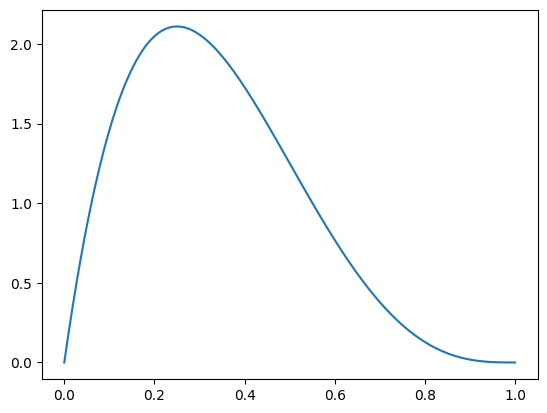

In [39]:
x_list = np.linspace(0, 1, 1000)
y_list = distr.pdf(x_list)
plt.plot(x_list, y_list);

## Dirichlet

In [40]:
dist = scipy.stats.dirichlet(alpha=[0.1, 0.2, 0.6])
dist.rvs()

array([[1.10108147e-05, 1.03750725e-01, 8.96238264e-01]])

## Normal

(np.float64(1.4189385332046727), np.float64(1.4189302845835194))

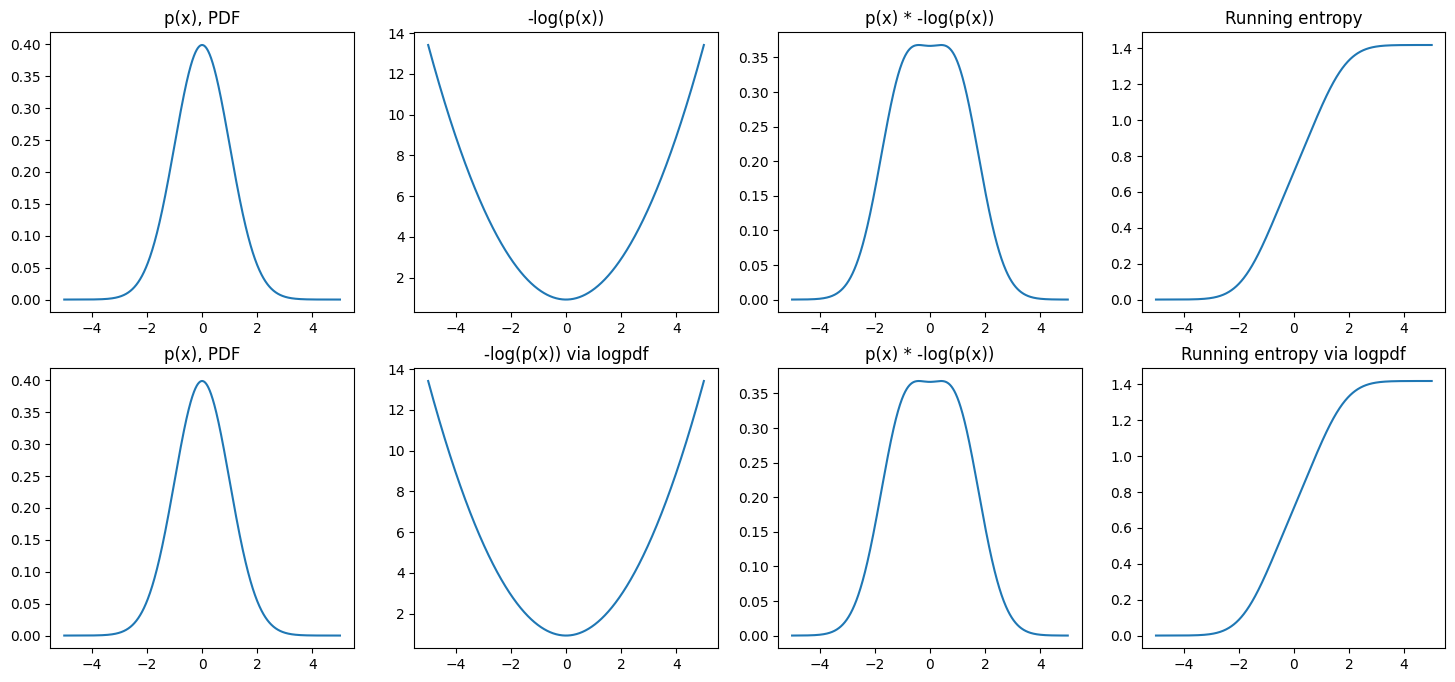

In [93]:
dist = scipy.stats.norm()
x_list = np.linspace(-5, 5, 1000)
dx = x_list[1] - x_list[0]
y_list = dist.pdf(x_list)

fig, axes = plt.subplots(2, 4)
fig.set_figwidth(18)
fig.set_figheight(8)

ax1, ax2, ax3, ax4 = axes[0]
ax1.set_title('p(x), PDF')
ax1.plot(x_list, y_list);
ax2.set_title('-log(p(x))')
ax2.plot(x_list, -np.log(y_list));
ax3.set_title('p(x) * -log(p(x))')
ax3.plot(x_list, y_list * -np.log(y_list));
ax4.set_title('Running entropy')
ax4.plot(x_list, np.cumsum(dx * (y_list * -np.log(y_list))));

ax1, ax2, ax3, ax4 = axes[1]
ax1.set_title('p(x), PDF')
ax1.plot(x_list, y_list);
ax2.set_title('-log(p(x)) via logpdf')
ax2.plot(x_list, -dist.logpdf(x_list));
ax3.set_title('p(x) * -log(p(x))')
ax3.plot(x_list, y_list * -dist.logpdf(x_list));
ax4.set_title('Running entropy via logpdf')
ax4.plot(x_list, np.cumsum(dx * (y_list * -dist.logpdf(x_list))));

# Для непрерывного распределения dx (ширина) требует явной обработки. Для дискретного распределения dx уже "зашито" в вероятность (вероятность = площадь), поэтому
# в формуле ожидания дискретной случ. величины и нет dx.
# Далее, для дискретного случая вместо PDF мы имеем PFM (probability mass function). Mass как бы подсказывает, что мы имеем дело уже с кирпичём (площадь), а не с 
# likelihood (чем-то похоже на фотон, который не имеет массы)
dist.entropy(), scipy.integrate.trapezoid(y_list * -dist.logpdf(x_list), x_list)